In [1]:
import sys
sys.path.append('../datasets')
sys.path.append('../algorithms')
sys.path.append('../test')


import torch

import matplotlib.pyplot as plt


from pansharpening import PANDataset
from alg2 import PANTVCB
from torchvision import transforms
from math import sqrt

/home/ndiayem/Documents/spectral-spatial/env/lib/python3.11/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [26]:
#Define device (default is "cpu")
device = "cpu" 

    # Define dtype
dtype = torch.float64
crop_size = 256

    # Define random seed
seed = 42
torch.manual_seed(seed)

    # Define data path
data_path = '/home/ndiayem/Documents/spectral-spatial/data/harvard.zarr'

In [27]:
val_transform = transforms.Compose([transforms.CenterCrop(crop_size)]) # Transforms a the input data to torch tensors
dataset = PANDataset(root_dir=data_path, split='train' ,transform=val_transform,normalize= True,scale=2,sigma=0.1,device='cpu', size=crop_size)

In [28]:
idx = 17
X = dataset[idx]
X = X.unsqueeze(0)

In [29]:
X.shape

torch.Size([1, 31, 256, 256])

In [30]:
# Matrice de transformation
Y_H = dataset.simulate_low_res_hsi(X)  
Y_M = dataset.get_panchromatic(X)



In [31]:
Y_H.shape

torch.Size([1, 31, 128, 128])

In [32]:
Y_M.shape

torch.Size([1, 1, 256, 256])

In [33]:
params = {
    'max_iter': 100,         # niters → max_iter (nom attendu par TVPrior)
    'lmbda': 1e-2,          # paramètre supplémentaire
    'theta': 1 ,            # paramètre de régularisation
    'sigma': 2,                  # sigma = gain (gain=2)   
    'tau': 0.99/2,              # tau = 0.99 / gain (calculé)             ²
}


In [34]:
A,A_adj, R, R_adj = dataset.get_operators()

solver_gp = PANTVCB(
    A=A,
    Aadj=A_adj,
    spectral_op = dataset.spectral_op,
    spectral_op_t = dataset.spectral_op_t,
    max_iter=500,
    lmbda=1e-2,
    lmbda_m=5,
    tol=1e-7,
    scale=dataset.scale,
    p = 1,
    q = 1,
    r = 1,
    verbose=True,
    params = params
)

In [35]:
U_cb, costs_gp = solver_gp(Y_H, Y_M)


Début de l'optimisation:
It    | Coût total   | Data H       | Data M       | TV           | ΔU          
--------------------------------------------------------------------------------
0     | 4.615e+03    | 3.119e+03    | 1.467e+03    | 2.931e+01    | 1.121e-02   
10    | 4.295e+03    | 2.905e+03    | 1.354e+03    | 3.537e+01    | 9.739e-03   
20    | 4.000e+03    | 2.707e+03    | 1.251e+03    | 4.321e+01    | 8.565e-03   
30    | 3.729e+03    | 2.522e+03    | 1.155e+03    | 5.158e+01    | 7.611e-03   
40    | 3.478e+03    | 2.351e+03    | 1.067e+03    | 6.010e+01    | 6.820e-03   
50    | 3.246e+03    | 2.192e+03    | 9.857e+02    | 6.861e+01    | 6.155e-03   
60    | 3.032e+03    | 2.045e+03    | 9.107e+02    | 7.706e+01    | 5.589e-03   
70    | 2.834e+03    | 1.908e+03    | 8.415e+02    | 8.540e+01    | 5.102e-03   
80    | 2.652e+03    | 1.780e+03    | 7.777e+02    | 9.361e+01    | 4.679e-03   
90    | 2.482e+03    | 1.662e+03    | 7.188e+02    | 1.017e+02    | 4.307e-03   
10

In [39]:
U_cb.shape

torch.Size([1, 31, 256, 256])

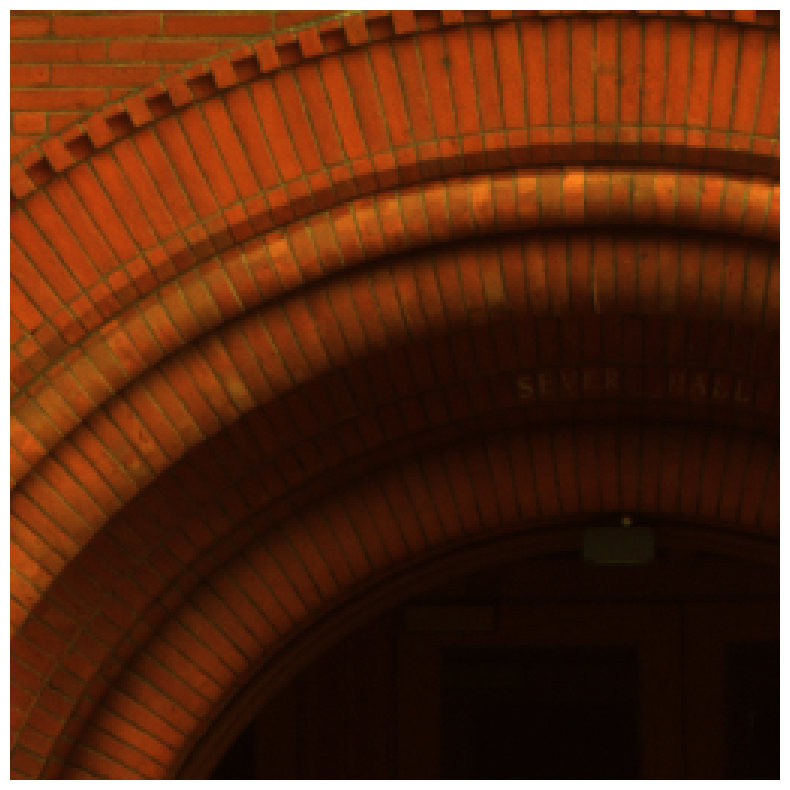

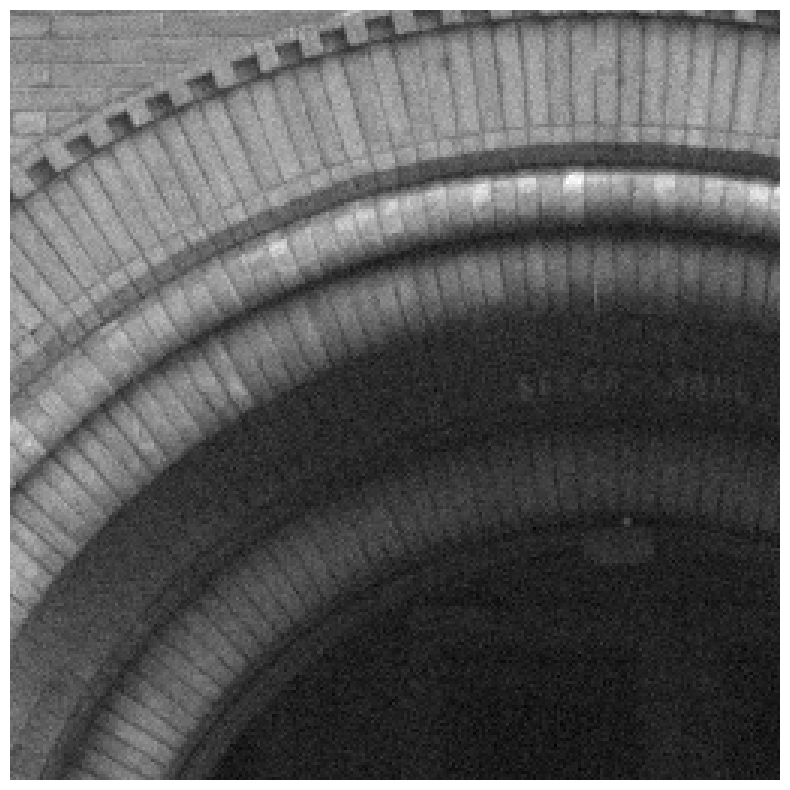

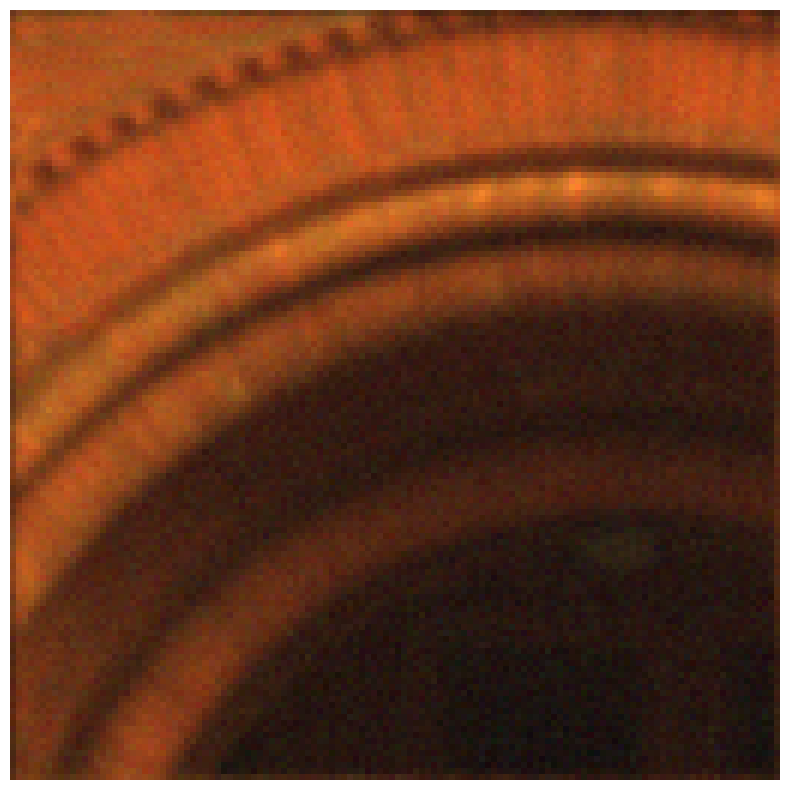

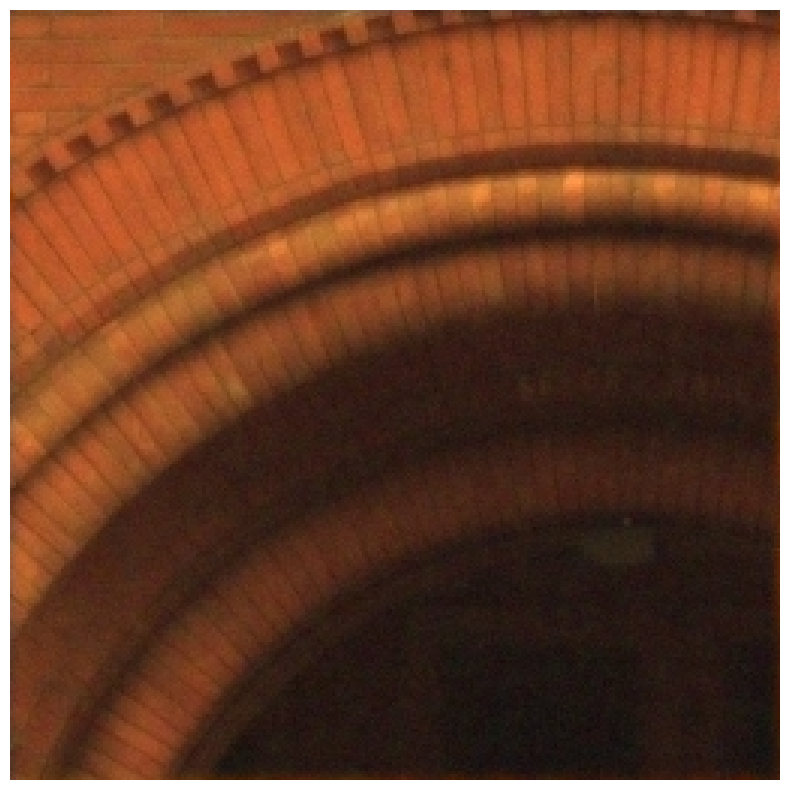

In [40]:
rgb = dataset.rgb_index
x_rgb = X[0, rgb,...].cpu().numpy().transpose(1, 2, 0)
x_rgb = (x_rgb - x_rgb.min())/(x_rgb.max() - x_rgb.min())

y_rgb = Y_H[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
y_rgb = (y_rgb - y_rgb.min())/(y_rgb.max() - y_rgb.min())

z_rgb = U_cb[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
z_rgb = (z_rgb - z_rgb.min())/(z_rgb.max() - z_rgb.min())

# plt.figure(figsize=(15, 5))
# plt.subplot(131)
plt.figure(figsize=(10,10))
plt.imshow(x_rgb)
# plt.title('RGB')
plt.axis('off')

# plt.subplot(132)
plt.figure(figsize=(10,10))
plt.imshow(Y_M[0, 0, ...].cpu().numpy(), cmap='gray')
# plt.title('Panchromatic')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(y_rgb)
# plt.title('Noisy RGB')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(z_rgb)
# plt.title('Noisy RGB')
plt.axis('off')

plt.show()

Dimensions vérifiées: iterations (500,), cout_total 500


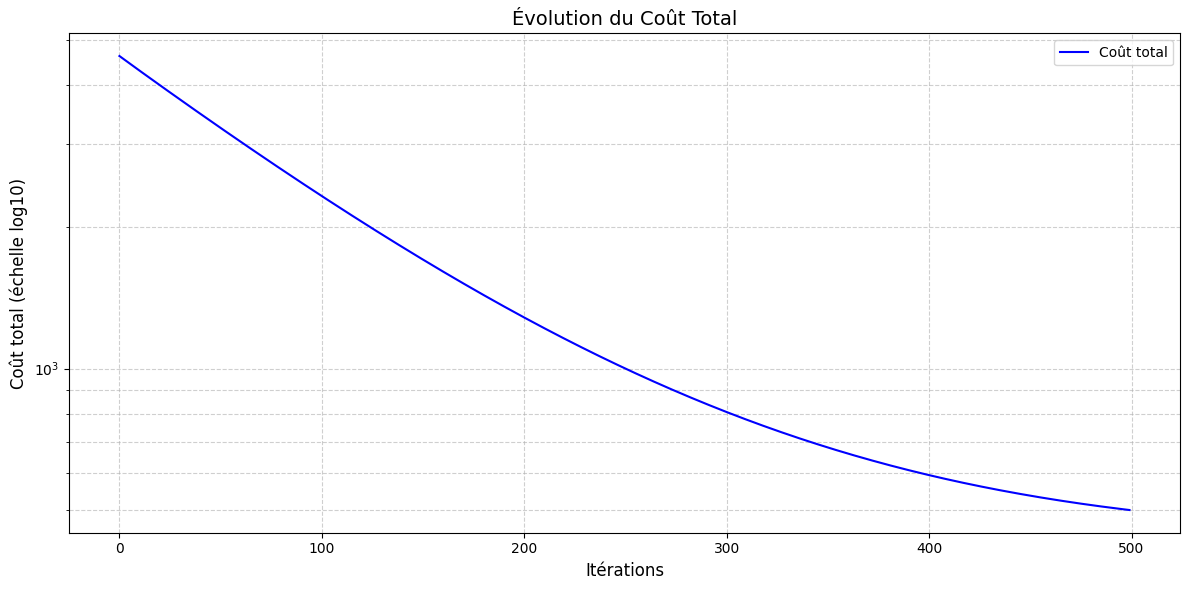

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Données d'exemple (à adapter avec vos données réelles)
cout_total = costs_gp

# Création du vecteur d'itérations de même longueur que cout_total
iterations = np.arange(0, len(cout_total))  # Pas de 10 entre les mesures

# Vérification des dimensions
print(f"Dimensions vérifiées: iterations {iterations.shape}, cout_total {len(cout_total)}")

# Création du graphique
plt.figure(figsize=(12, 6))
plt.semilogy(iterations, cout_total, 'b-', linewidth=1.5, label='Coût total')

# Personnalisation
plt.xlabel('Itérations', fontsize=12)
plt.ylabel('Coût total (échelle log10)', fontsize=12)
plt.title('Évolution du Coût Total', fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.6)

# Affichage
plt.legend()
plt.tight_layout()
plt.show()